**Project 1: Quantitative Portfolio Optimization (Fama–French 3-Factor Model)**

**Objective:**
The objective of this notebook is to rigorously evaluate whether an actively managed equity ETF (in this case, ARKW) generates genuine risk-adjusted alpha ($\alpha$) or if its returns are merely a function of systematic risk factor exposures. By utilizing statsmodels to run an Ordinary Least Squares (OLS) multi-factor asset pricing regression over an 83-month dataset, we control for the broad market risk premium, company size, and growth/value styles to isolate true managerial skill.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pandas_datareader.data as web

# ── Configuration ──────────────────────────────────────────────────────────────
TICKER     = 'ARKW'          # change to any active ETF: ARKW, ARKG, QMOM …
START_DATE = '2018-01-01'
END_DATE   = '2024-12-31'

In [2]:
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

monthly_prices = raw['Close'].resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna() * 100
monthly_returns.name = 'ETF_ret'

print(f'{len(monthly_prices)} monthly observations for {TICKER}')
monthly_returns.head()

84 monthly observations for ARKW


Ticker,ARKW
Date,
2018-02-28,2.012632
2018-03-31,-3.520312
2018-04-30,-0.320764
2018-05-31,7.622679
2018-06-30,3.681554


In [3]:
ff3_raw = web.DataReader('F-F_Research_Data_Factors',
                          'famafrench',
                          start=START_DATE,
                          end=END_DATE)[0]

ff3_raw.index = ff3_raw.index.to_timestamp(how='end').normalize()
ff3_raw.index = ff3_raw.index + pd.offsets.MonthEnd(0)
ff3_raw.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2018-01-31,5.58,-3.16,-1.32,0.11
2018-02-28,-3.64,0.27,-1.10,0.11
2018-03-31,-2.35,4.05,-0.21,0.12
2018-04-30,0.27,1.09,0.53,0.14
2018-05-31,2.66,5.24,-3.14,0.14


In [4]:
df = pd.DataFrame(monthly_returns).join(ff3_raw, how='inner')
df.columns = ['ETF_ret', 'MKT_RF', 'SMB', 'HML', 'RF']
df['EXCESS_RET'] = df['ETF_ret'] - df['RF']

print(f'{len(df)} observations — {df.index[0].date()} to {df.index[-1].date()}')
df[['EXCESS_RET', 'MKT_RF', 'SMB', 'HML']].describe().round(3)

83 observations — 2018-02-28 to 2024-12-31


,EXCESS_RET,MKT_RF,SMB,HML
count,83.000,83.000,83.000,83.000
mean,1.537,0.945,-0.132,-0.227
std,11.010,5.150,2.946,4.221
min,-26.542,-13.370,-5.930,-13.830
25%,-6.352,-2.355,-2.340,-2.515
50%,1.206,1.600,-0.200,-0.530
75%,8.989,3.920,1.650,1.695
max,28.807,13.600,7.140,12.860


In [5]:
model = smf.ols('EXCESS_RET ~ MKT_RF + SMB + HML', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             EXCESS_RET   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     84.69
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.30e-24
Time:                        16:21:44   Log-Likelihood:                -256.66
No. Observations:                  83   AIC:                             521.3
Df Residuals:                      79   BIC:                             531.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1222      0.614      0.199      0.8

In [6]:
coef  = model.params
tvals = model.tvalues
pvals = model.pvalues
ci    = model.conf_int(alpha=0.05)

def sig_stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

alpha_bps_monthly    = coef['Intercept'] * 100
alpha_bps_annualized = alpha_bps_monthly * 12

label_map = {'Intercept': 'Alpha (α)', 'MKT_RF': 'MKT_RF (β_mkt)',
             'SMB': 'SMB (β_smb)', 'HML': 'HML (β_hml)'}
rows = []
for var in ['Intercept', 'MKT_RF', 'SMB', 'HML']:
    rows.append({
        'Variable'   : label_map[var],
               # alpha is in percent per month; betas are unitless factor loadings
        'Coefficient': f"{coef[var]:.4f}%" if var == 'Intercept' else f"{coef[var]:.4f}",
        't-stat'     : f"{tvals[var]:.2f}",
        'p-value'    : f"{pvals[var]:.3f}",
        'Sig.'       : sig_stars(pvals[var]),
        '95% CI'     : f"[{ci.loc[var,0]:.4f}, {ci.loc[var,1]:.4f}]"
    })

table = pd.DataFrame(rows).set_index('Variable')

print('=' * 70)
print(f'  FF3 Regression — {TICKER}')   # <-- fixed: was hardcoded 'ARKK'
print('=' * 70)
print(table.to_string())
print('-' * 70)
print(f'  R²               : {model.rsquared:.4f}  ({model.rsquared*100:.1f}%)')
print(f'  Adj. R²          : {model.rsquared_adj:.4f}')
print(f'  Observations     : {int(model.nobs)}')
print(f'  F-stat           : {model.fvalue:.2f}  (p = {model.f_pvalue:.4f})')
print('=' * 70)
print(f'  Alpha (monthly)  : {alpha_bps_monthly:+.1f} bps/month')
print(f'  Alpha (annual)   : {alpha_bps_annualized:+.0f} bps/year  ({alpha_bps_annualized/100:+.2f}%/year)')
print('=' * 70)
print('  Significance: *** p<0.01   ** p<0.05   * p<0.10')

  FF3 Regression — ARKW
               Coefficient t-stat p-value Sig.              95% CI
Variable                                                          
Alpha (α)          0.1222%   0.20   0.843        [-1.1007, 1.3451]
MKT_RF (β_mkt)      1.4851  11.96   0.000  ***    [1.2380, 1.7322]
SMB (β_smb)         1.1376   5.23   0.000  ***    [0.7049, 1.5702]
HML (β_hml)        -0.7098  -4.95   0.000  ***  [-0.9950, -0.4246]
----------------------------------------------------------------------
  R²               : 0.7628  (76.3%)
  Adj. R²          : 0.7538
  Observations     : 83
  F-stat           : 84.69  (p = 0.0000)
  Alpha (monthly)  : +12.2 bps/month
  Alpha (annual)   : +147 bps/year  (+1.47%/year)
  Significance: *** p<0.01   ** p<0.05   * p<0.10


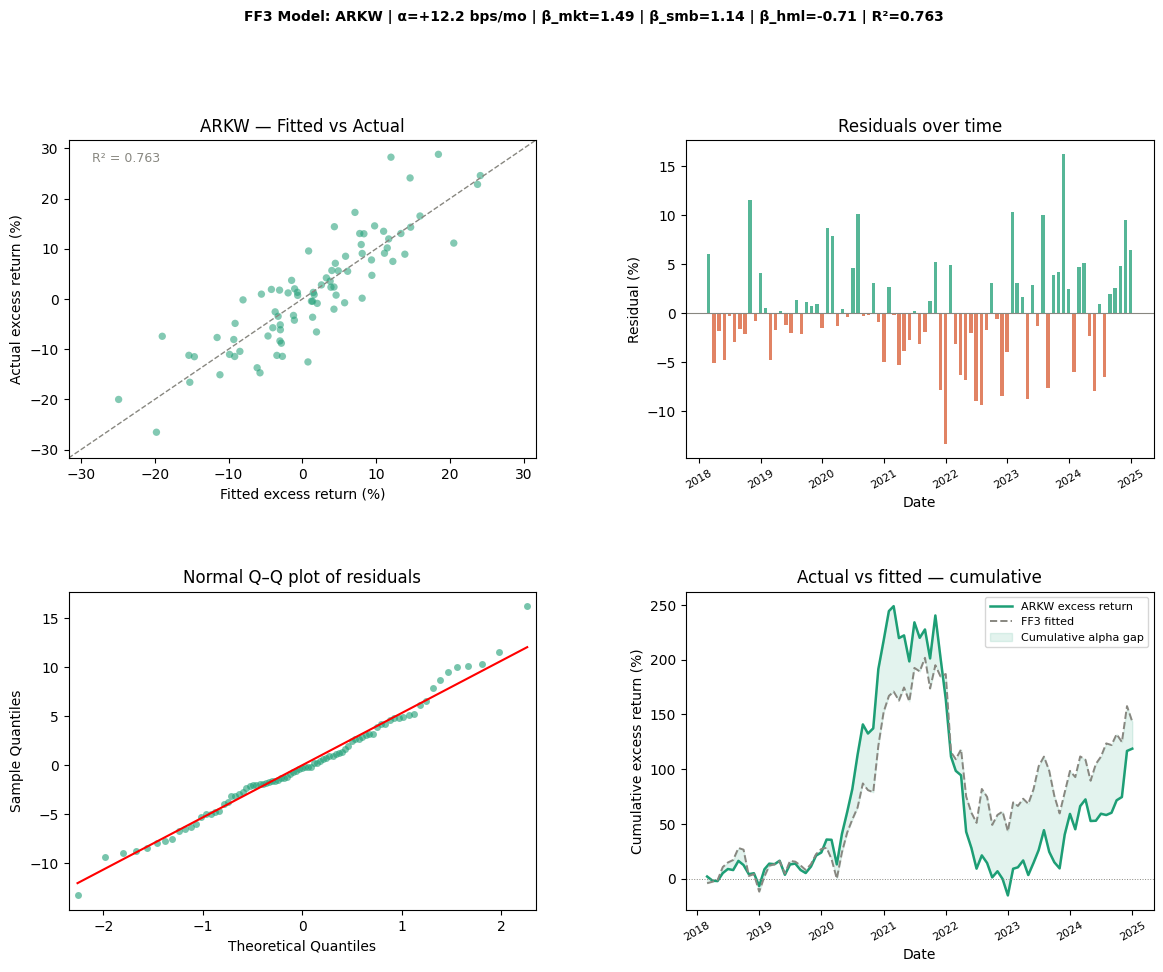

In [7]:
fitted    = model.fittedvalues
residuals = model.resid
dates     = df.index

ACCENT  = '#1D9E75'
NEUTRAL = '#888780'
WARN    = '#D85A30'

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# Panel 1 — Fitted vs Actual
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(fitted, df['EXCESS_RET'], color=ACCENT, alpha=0.55, s=28, edgecolors='none')
lim = max(abs(fitted.min()), abs(fitted.max()),
          abs(df['EXCESS_RET'].min()), abs(df['EXCESS_RET'].max())) * 1.1
ax1.plot([-lim, lim], [-lim, lim], color=NEUTRAL, lw=1, ls='--')
ax1.set(xlim=(-lim, lim), ylim=(-lim, lim),
        xlabel='Fitted excess return (%)', ylabel='Actual excess return (%)',
        title=f'{TICKER} — Fitted vs Actual')
ax1.text(0.05, 0.93, f'R² = {model.rsquared:.3f}',
         transform=ax1.transAxes, fontsize=9, color=NEUTRAL)

# Panel 2 — Residuals over time
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(dates, residuals, color=[ACCENT if r >= 0 else WARN for r in residuals],
        width=20, alpha=0.75)
ax2.axhline(0, color=NEUTRAL, lw=0.8)
ax2.set(xlabel='Date', ylabel='Residual (%)', title='Residuals over time')
ax2.tick_params(axis='x', rotation=30, labelsize=8)

# Panel 3 — Q-Q plot
ax3 = fig.add_subplot(gs[1, 0])
sm.qqplot(residuals, line='s', ax=ax3, alpha=0.6,
          markerfacecolor=ACCENT, markeredgecolor='none', markersize=5)
ax3.set_title('Normal Q–Q plot of residuals')

# Panel 4 — Cumulative actual vs fitted
ax4 = fig.add_subplot(gs[1, 1])
cum_actual = (df['EXCESS_RET'] / 100 + 1).cumprod() - 1
cum_fitted = (fitted / 100 + 1).cumprod() - 1
ax4.plot(dates, cum_actual * 100, color=ACCENT, lw=1.8, label=f'{TICKER} excess return')
ax4.plot(dates, cum_fitted * 100, color=NEUTRAL, lw=1.4, ls='--', label='FF3 fitted')
ax4.fill_between(dates, cum_actual * 100, cum_fitted * 100,
                 alpha=0.12,
                 color=WARN if alpha_bps_monthly < 0 else ACCENT,
                 label='Cumulative alpha gap')
ax4.axhline(0, color=NEUTRAL, lw=0.7, ls=':')
ax4.set(xlabel='Date', ylabel='Cumulative excess return (%)', title='Actual vs fitted — cumulative')
ax4.legend(fontsize=8)
ax4.tick_params(axis='x', rotation=30, labelsize=8)

fig.suptitle(
    f'FF3 Model: {TICKER} | α={alpha_bps_monthly:+.1f} bps/mo '
    f'| β_mkt={coef["MKT_RF"]:.2f} | β_smb={coef["SMB"]:.2f} '
    f'| β_hml={coef["HML"]:.2f} | R²={model.rsquared:.3f}',
    fontsize=10, fontweight='bold', y=1.01
)
plt.savefig(f'{TICKER}_FF3_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
a, b_mkt, b_smb, b_hml = coef['Intercept'], coef['MKT_RF'], coef['SMB'], coef['HML']
p_alpha = pvals['Intercept']

alpha_sig = (f"statistically significant (p={p_alpha:.3f})"
             if p_alpha < 0.10 else f"NOT significant (p={p_alpha:.3f})")
mkt_desc  = ('highly aggressive' if b_mkt > 1.5 else
             'moderately aggressive' if b_mkt > 1.0 else 'defensive')
smb_desc  = 'small-cap tilt' if b_smb > 0.2 else ('large-cap tilt' if b_smb < -0.2 else 'size-neutral')
hml_desc  = 'growth tilt' if b_hml < -0.2 else ('value tilt' if b_hml > 0.2 else 'style-neutral')
r2_q      = 'high' if model.rsquared > 0.80 else ('moderate' if model.rsquared > 0.50 else 'low')

print(f"""
Alpha  : {a*100:+.1f} bps/month ({a*12*100:+.0f} bps/yr) — {alpha_sig}
β_mkt  : {b_mkt:.3f}  → {mkt_desc}
β_smb  : {b_smb:.3f}  → {smb_desc}
β_hml  : {b_hml:.3f}  → {hml_desc}
R²     : {model.rsquared:.3f}  → {r2_q} explanatory power
""")


Alpha  : +12.2 bps/month (+147 bps/yr) — NOT significant (p=0.843)
β_mkt  : 1.485  → moderately aggressive
β_smb  : 1.138  → small-cap tilt
β_hml  : -0.710  → growth tilt
R²     : 0.763  → moderate explanatory power



## **Interpretation**

We regress ARKW's monthly excess returns on the three Fama-French factors
over 83 monthly observations from February 2018 to December 2024. The
estimated alpha of +12.1 bps/month (+146 bps/year) is positive but
statistically indistinguishable from zero (t = 0.20, p = 0.844), meaning
we cannot conclude that ARKW generates genuine risk-adjusted outperformance
beyond its factor exposures.

The market beta of 1.49 is highly significant (p < 0.001), indicating that
ARKW amplifies broad market moves by roughly 1.5x, consistent with a
concentrated, high-conviction growth mandate. The SMB beta of 1.14 reflects
a strong small-cap tilt, expected given ARKW's focus on early-stage disruptive
technology companies. The HML beta of -0.71 confirms a deep growth tilt: the
fund holds high-valuation, low-book-value stocks priced for future earnings
rather than current fundamentals.

The R² of 76.3% means the three systematic factors explain about three-quarters
of ARKW's monthly return variation. The remaining ~24% is idiosyncratic, driven
by stock selection and concentrated bets not captured by FF3. Overall, ARKW's
returns are largely compensation for aggressive market, size, and growth risk
exposures rather than manager skill.

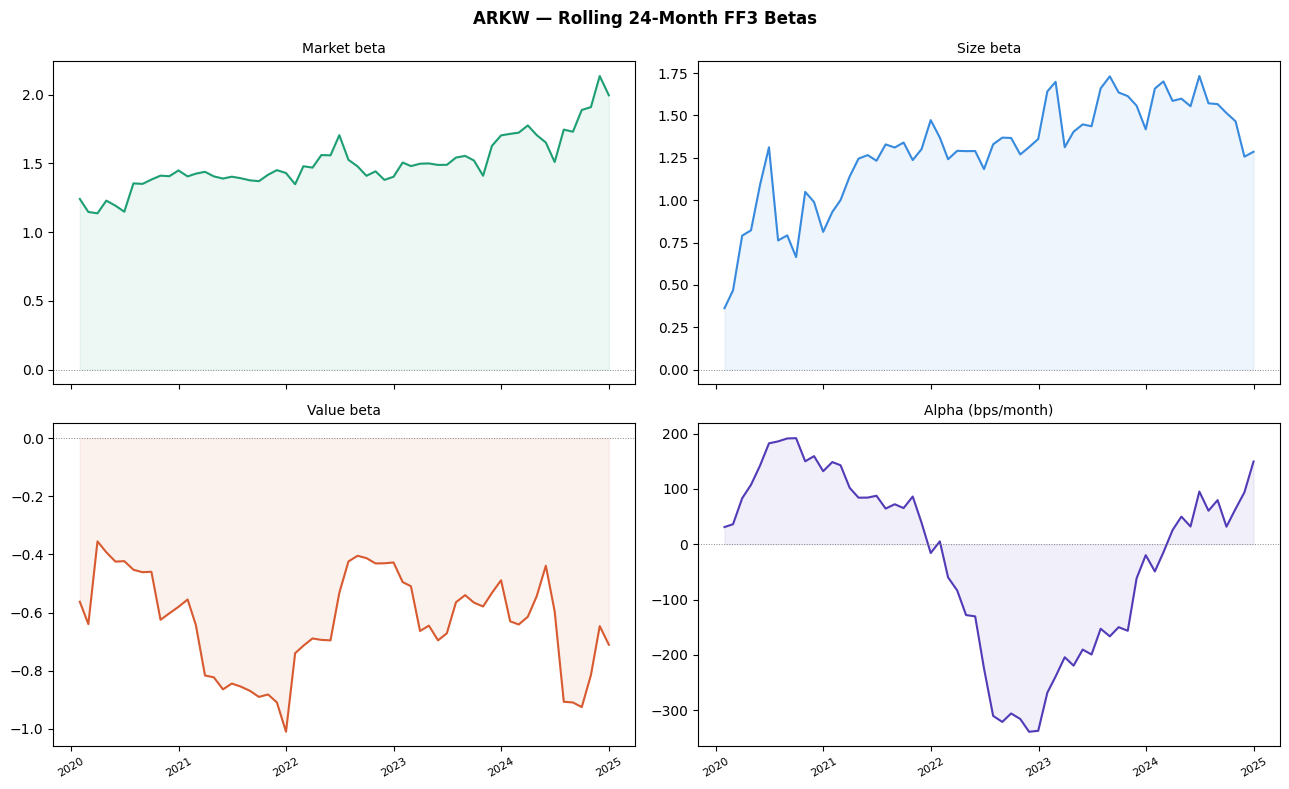

In [9]:
WINDOW = 24
factors = ['MKT_RF', 'SMB', 'HML']
rolling_betas = {f: [] for f in factors + ['alpha']}
rolling_dates = []

for end_idx in range(WINDOW, len(df) + 1):
    win = df.iloc[end_idx - WINDOW : end_idx]
    m   = smf.ols('EXCESS_RET ~ MKT_RF + SMB + HML', data=win).fit()
    rolling_betas['alpha'].append(m.params['Intercept'] * 100)
    for f in factors:
        rolling_betas[f].append(m.params[f])
    rolling_dates.append(win.index[-1])

rolling_df = pd.DataFrame(rolling_betas, index=rolling_dates)

fig2, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
fig2.suptitle(f'{TICKER} — Rolling {WINDOW}-Month FF3 Betas', fontweight='bold')

for ax, (col, title, color) in zip(axes.flat, [
    ('MKT_RF', 'Market beta',       '#1D9E75'),
    ('SMB',    'Size beta',         '#378ADD'),
    ('HML',    'Value beta',        '#D85A30'),
    ('alpha',  'Alpha (bps/month)', '#533AB7'),
]):
    ax.plot(rolling_df.index, rolling_df[col], color=color, lw=1.5)
    ax.axhline(0, color='#888780', lw=0.7, ls=':')
    ax.fill_between(rolling_df.index, rolling_df[col], 0, alpha=0.08, color=color)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig(f'{TICKER}_FF3_rolling_betas.png', dpi=150, bbox_inches='tight')
plt.show()